In [1]:
import pandas as pd


In [2]:
import os

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv(r'C:\Users\ramya\OneDrive\Desktop\Irish_housing_analytics\Data\Property_Price_Register_Ireland-28-05-2021.csv\Property_Price_Register_Ireland-28-05-2021.csv', low_memory=False)

In [7]:
print(f"Total rows: {len(df)}")

Total rows: 476745


In [ ]:
print(f"Columns: {df.columns.tolist()}")

In [8]:
print(f"Columns: {df.columns.tolist()}")

Columns: ['SALE_DATE', 'ADDRESS', 'POSTAL_CODE', 'COUNTY', 'SALE_PRICE', 'IF_MARKET_PRICE', 'IF_VAT_EXCLUDED', 'PROPERTY_DESC', 'PROPERTY_SIZE_DESC']


In [9]:
print(df.head())

    SALE_DATE                                         ADDRESS POSTAL_CODE  \
0  2010-01-01          5 Braemor Drive, Churchtown, Co.Dublin         NaN   
1  2010-01-03  134 Ashewood Walk, Summerhill Lane, Portlaoise         NaN   
2  2010-01-04             1 Meadow Avenue, Dundrum, Dublin 14         NaN   
3  2010-01-04                         1 The Haven, Mornington         NaN   
4  2010-01-04                   11 Melville Heights, Kilkenny         NaN   

     COUNTY  SALE_PRICE  IF_MARKET_PRICE  IF_VAT_EXCLUDED  \
0    Dublin    343000.0                0                0   
1     Laois    185000.0                0                1   
2    Dublin    438500.0                0                0   
3     Meath    400000.0                0                0   
4  Kilkenny    160000.0                0                0   

                           PROPERTY_DESC  \
0  Second-Hand Dwelling house /Apartment   
1          New Dwelling house /Apartment   
2  Second-Hand Dwelling house /Apartme

In [10]:
df.columns = df.columns.str.strip().str.lower()

In [12]:
df = df.rename(columns={'sale_price': 'price'})

In [13]:
print(df.columns.tolist())

['sale_date', 'address', 'postal_code', 'county', 'price', 'if_market_price', 'if_vat_excluded', 'property_desc', 'property_size_desc']


In [16]:
df = df.drop(columns=['postal_code', 'property_size_desc'], errors='ignore')

In [17]:
print(df.columns.tolist())

['sale_date', 'address', 'county', 'price', 'if_market_price', 'if_vat_excluded']


In [19]:
df['sale_date']=pd.to_datetime(df['sale_date'],dayfirst=True,errors='coerce')

In [20]:
df['year']=df['sale_date'].dt.year

In [21]:
df['month']=df['sale_date'].dt.month

In [22]:
print(df['year'].value_counts().sort_index())

year
2010.0     7792
2011.0     6824
2012.0     8965
2013.0    10783
2014.0    15684
2015.0    17395
2016.0    18195
2017.0    20198
2018.0    20326
2019.0    22409
2020.0    17960
2021.0     7243
Name: count, dtype: int64


In [23]:
print(f"Remaining columns: {df.columns.tolist()}")

Remaining columns: ['sale_date', 'address', 'county', 'price', 'if_market_price', 'if_vat_excluded', 'year', 'month']


In [24]:
df = df.dropna(subset=['price', 'sale_date', 'county'])

In [25]:
df = df[df['not_market'] == 0]

KeyError: 'not_market'

In [26]:
df = df[(df['price'] >= 10_000) & (df['price'] <= 5_000_000)]

In [27]:
print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 173375


In [28]:
df['county'] = df['county'].str.strip().str.title()

In [29]:
print(df['county'].value_counts().head(10))

county
Dublin      55899
Cork        18834
Kildare      8806
Galway       8733
Meath        7042
Limerick     6445
Wexford      5898
Wicklow      5463
Kerry        5031
Donegal      4667
Name: count, dtype: int64


In [31]:
summary = (
    df.groupby(['year', 'county'])
    .agg(
        avg_price    = ('price', 'mean'),
        median_price = ('price', 'median'),
        num_sales    = ('price', 'count')
    )
    .reset_index()
    .round(0)
)

In [32]:
print(summary[summary['county'] == 'Dublin'])

       year  county  avg_price  median_price  num_sales
5    2010.0  Dublin   325275.0      270000.0       2623
31   2011.0  Dublin   302716.0      237885.0       2200
57   2012.0  Dublin   273101.0      200000.0       3273
83   2013.0  Dublin   296903.0      220000.0       3733
109  2014.0  Dublin   325270.0      250000.0       5437
135  2015.0  Dublin   338080.0      270000.0       5496
161  2016.0  Dublin   377797.0      298000.0       5630
187  2017.0  Dublin   405638.0      322500.0       6648
213  2018.0  Dublin   417006.0      334802.0       6480
239  2019.0  Dublin   413066.0      337000.0       6814
265  2020.0  Dublin   430494.0      355000.0       5426
291  2021.0  Dublin   449655.0      361233.0       2139


In [35]:
print(summary[summary['county'] == 'Limerick'])

     year    county  avg_price  median_price  num_sales
12   2010  Limerick   198516.0      175606.0        304
38   2011  Limerick   166952.0      160000.0        281
64   2012  Limerick   151837.0      127000.0        283
90   2013  Limerick   146102.0      120000.0        317
116  2014  Limerick   123433.0      102500.0        575
142  2015  Limerick   135102.0      105000.0        751
168  2016  Limerick   145204.0      130000.0        677
194  2017  Limerick   171232.0      152000.0        706
220  2018  Limerick   198592.0      175000.0        778
246  2019  Limerick   205253.0      180000.0        824
272  2020  Limerick   211939.0      195000.0        676
298  2021  Limerick   200192.0      175000.0        273


In [34]:
summary['year'] = summary['year'].astype(int)
df['year']      = df['year'].astype(int)

In [41]:
df.to_csv(r'C:\Users\ramya\OneDrive\Desktop\Irish_housing_analytics\Data\ppr_clean.csv', index=False)
summary.to_csv(r'C:\Users\ramya\OneDrive\Desktop\Irish_housing_analytics\Data\ppr_summary.csv', index=False)

print("Done — files saved")

Done — files saved


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the clean files we saved in Step 1
df      = pd.read_csv(r'C:\Users\ramya\OneDrive\Desktop\Irish_housing_analytics\Data\ppr_clean.csv')
summary = pd.read_csv(r'C:\Users\ramya\OneDrive\Desktop\Irish_housing_analytics\Data\ppr_summary.csv')

print(f"Rows: {len(df)}")
print(summary.head())

Rows: 173375
   year   county  avg_price  median_price  num_sales
0  2010   Carlow   173586.0      158150.0         84
1  2010    Cavan   153090.0      135000.0        118
2  2010    Clare   184100.0      160625.0        200
3  2010     Cork   223536.0      206805.0        816
4  2010  Donegal   148993.0      130000.0        231


In [43]:
# Filter summary for Dublin only
dublin = summary[summary['county'] == 'Dublin'].sort_values('year')

In [49]:
# Create the chart
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

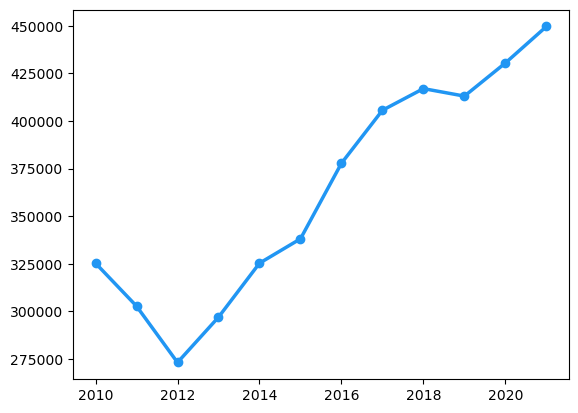

In [46]:
plt.plot(dublin['year'], dublin['avg_price'],
         color='#2196F3', linewidth=2.5,
         marker='o', markersize=6, label='Average price')

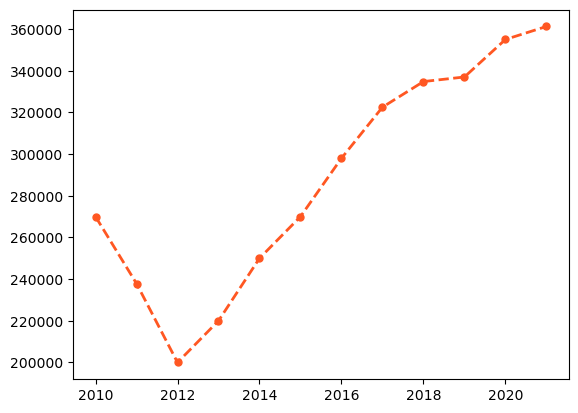

In [50]:
plt.plot(dublin['year'], dublin['median_price'],
         color='#FF5722', linewidth=2, linestyle='--',
         marker='o', markersize=5, label='Median price')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


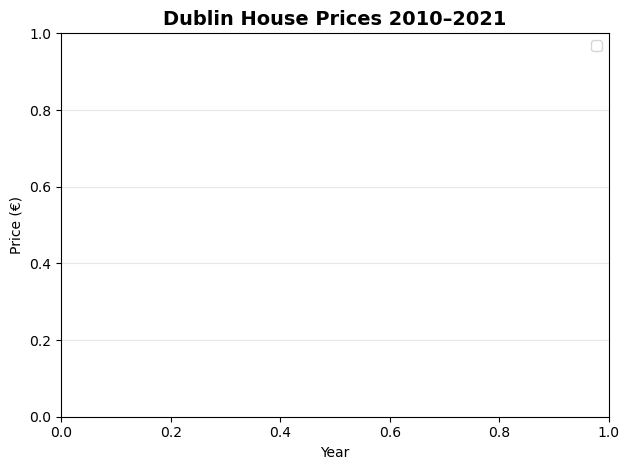

In [51]:
plt.title('Dublin House Prices 2010–2021', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (€)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

In [ ]:
plt.savefig(r'C:\Users\ramya\OneDrive\Desktop\Irish_housing_analytics\Charts\dublin_price_trend.png', dpi=150)
plt.show()
print("✅ Chart 1 saved")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ramya\\OneDrive\\Desktop\\Irish_housing_analytics\\Charts\\dublin_price_trend.png'

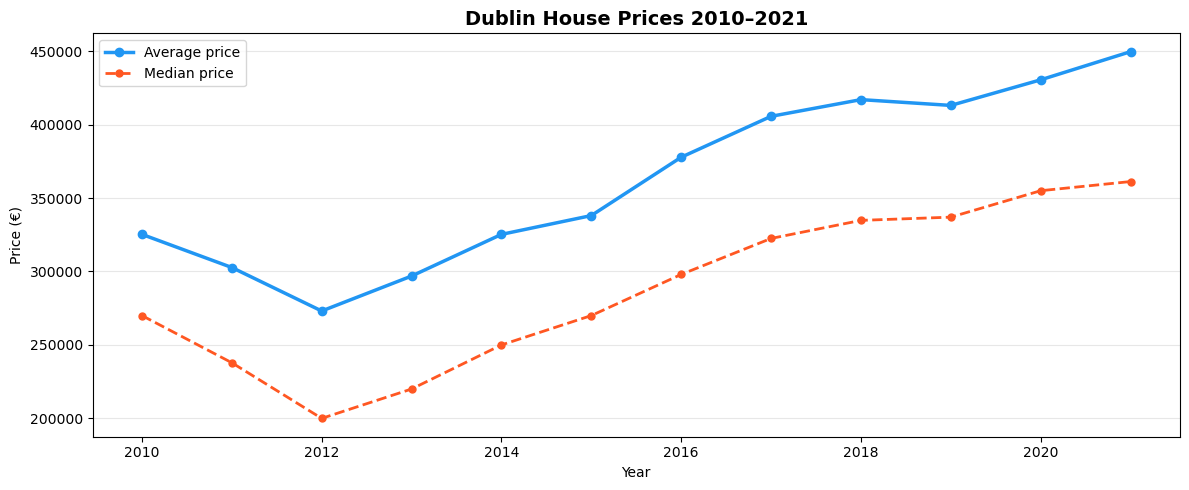

In [53]:
# Filter Dublin data
dublin = summary[summary['county'] == 'Dublin'].sort_values('year')

# Create chart
plt.figure(figsize=(12, 5))

# Line 1 — Average price (blue solid line)
plt.plot(dublin['year'], dublin['avg_price'],
         color='#2196F3', linewidth=2.5,
         marker='o', markersize=6, label='Average price')

# Line 2 — Median price (orange dashed line)
plt.plot(dublin['year'], dublin['median_price'],
         color='#FF5722', linewidth=2, linestyle='--',
         marker='o', markersize=5, label='Median price')

# Formatting
plt.title('Dublin House Prices 2010–2021', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (€)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig(r'C:\Users\ramya\OneDrive\Desktop\Irish_housing_analytics\Charts\dublin_price_trend.png', dpi=150)
plt.show()
print("✅ Chart 1 saved")

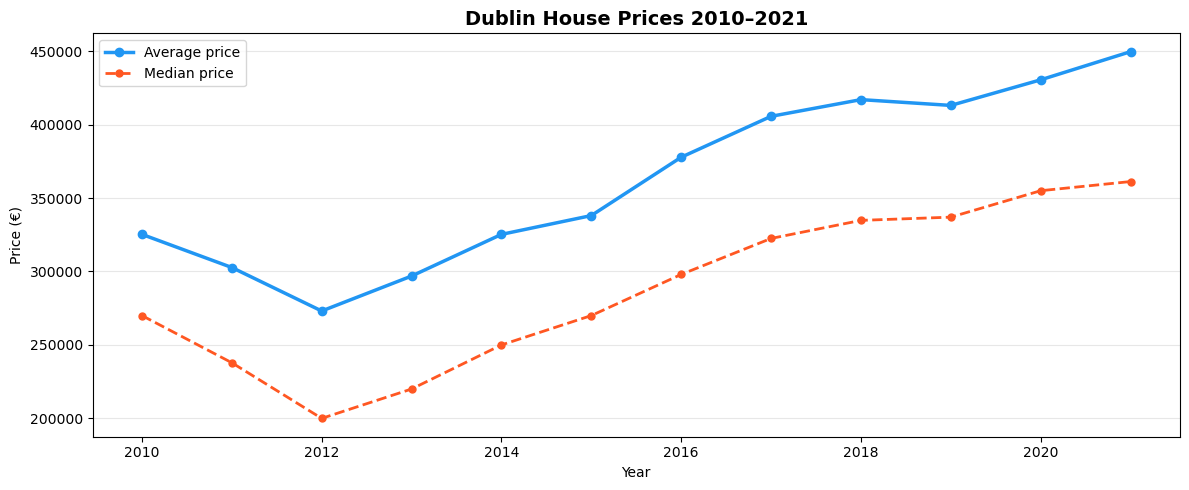

Chart 1 saved


In [55]:
import matplotlib.pyplot as plt
import os

# Filter Dublin data
dublin = summary[summary['county'] == 'Dublin'].sort_values('year')

# Create Charts folder if it doesn't exist
os.makedirs(r'C:\Users\ramya\OneDrive\Desktop\Irish_housing_analytics\Charts', exist_ok=True)

# Create chart
plt.figure(figsize=(12, 5))

# Line 1 — Average price
plt.plot(dublin['year'], dublin['avg_price'],
         color='#2196F3', linewidth=2.5,
         marker='o', markersize=6, label='Average price')

# Line 2 — Median price
plt.plot(dublin['year'], dublin['median_price'],
         color='#FF5722', linewidth=2, linestyle='--',
         marker='o', markersize=5, label='Median price')

# Formatting
plt.title('Dublin House Prices 2010–2021', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (€)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig(r'C:\Users\ramya\OneDrive\Desktop\Irish_housing_analytics\Charts\dublin_price_trend.png', dpi=150)
plt.show()
print("Chart 1 saved")

In [57]:
# Filter to 2021 and sort by price
top_counties = (summary[summary['year'] == 2021]
                .sort_values('avg_price', ascending=False)
                .head(10))

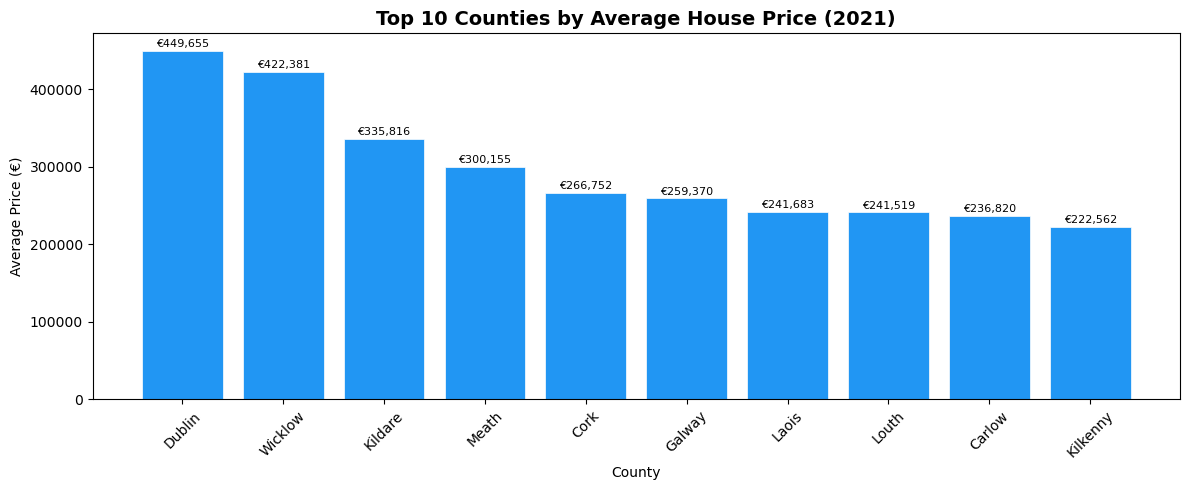

 Chart 2 saved


In [63]:
top_counties = (summary[summary['year'] == 2021]
                .sort_values('avg_price', ascending=False)
                .head(10))

plt.figure(figsize=(12, 5), dpi=100)

bars = plt.bar(top_counties['county'], top_counties['avg_price'],
               color='#2196F3', edgecolor='white', linewidth=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2000,
             f'€{int(height):,}', ha='center', va='bottom', fontsize=8)

plt.title('Top 10 Counties by Average House Price (2021)', fontsize=14, fontweight='bold')
plt.xlabel('County')
plt.ylabel('Average Price (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\ramya\OneDrive\Desktop\Irish_housing_analytics\Charts\top_counties_2021.png',
            dpi=100, bbox_inches='tight')
plt.show()
print(" Chart 2 saved")